<a href="https://colab.research.google.com/github/Abe-Alefew/ModelConfidenceTraining/blob/main/iCogTrainingSelf_Information.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Understanding Model Confidence and Loss Using Entropy & Cross-Entropy

## Task Overview
This notebook explores how entropy measures prediction uncertainty and how
cross-entropy functions as a loss function in classification.

We will:
- Train a Multiclass Logistic Regression on Fashion-MNIST
- Implement entropy and cross-entropy manually from their mathematical definitions
- Use our own cross-entropy as the training loss
- Analyze model confidence: what high and low entropy reveal about predictions


In [ ]:
#importing
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt

In [ ]:
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device -> {device}")

Using device -> cuda


## Dataset: Fashion-MNIST

- 60,000 training / 10,000 test samples
- 10 classes: T-shirt, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot
- Each image: 28×28 grayscale → flattened to 784-dim vector for logistic regression
- Normalization: pixel values scaled to [-1, 1]

In [ ]:
# Constants
BATCH_SIZE  = 64
NUM_CLASSES = 10
INPUT_DIM   = 784   # 28 × 28

CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# Transforms
# ToTensor()       → converts PIL image [0,255] to float tensor [0.0, 1.0]
# Normalize(0.5, 0.5) → shifts to [-1, 1]: (x - 0.5) / 0.5
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load datasets
train_dataset = torchvision.datasets.FashionMNIST(
    root="./data", train=True,  download=True, transform=transform
)
test_dataset  = torchvision.datasets.FashionMNIST(
    root="./data", train=False, download=True, transform=transform
)

#  DataLoaders
# shuffle=True for training: prevents the model from memorizing order, to learn patterns
# shuffle=False for test:    order doesn't matter; we just need all samples
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)


print(f"\nTraining samples : {len(train_dataset)}")
print(f"Test samples     : {len(test_dataset)}")
print(f"Batches per epoch: {len(train_loader)}")

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 171kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.15MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 15.0MB/s]


Training samples : 60000
Test samples     : 10000
Batches per epoch: 938


## Model: Multiclass Logistic Regression

Architecture: Linear(784 → 10) followed by Softmax

- No hidden layers: this is the simplest possible classifier
- Softmax converts raw logit scores into probabilities that sum to 1
- The model learns a weight matrix W (784×10) and bias b (10,)
- Training adjusts W and b to minimize cross-entropy loss

Why this model? The focus is on analyzing entropy and cross-entropy,
not on achieving maximum accuracy.

In [ ]:
class LogisticRegression(nn.Module):


    def __init__(self, input_dim: int, num_classes: int):
        super().__init__()
        # nn.Linear: applies the transformation x @ W.T + b
        # input_dim  → 784 (flattened 28×28 image)
        # num_classes → 10
        self.linear = nn.Linear(input_dim, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:

        # Flatten: (batch_size, 1, 28, 28) → (batch_size, 784), why? because nn.Linear expects (bacth_size,features)
        # x.size(0) is the batch size; -1 tells PyTorch to infer the rest
        x = x.view(x.size(0), -1)

        # Linear layer: (batch_size, 784) → (batch_size, 10)
        logits = self.linear(x)

        # Softmax: convert logits to probabilities along class dimension (dim=1)
        # dim=1 means "apply softmax across the 10 class scores for each sample"
        probs = F.softmax(logits, dim=1)

        return probs


#  Instantiate the model and move it to the correct device
model = LogisticRegression(INPUT_DIM, NUM_CLASSES).to(device)

#  Optimizer
# SGD with momentum: a standard choice. lr=0.01 is a reasonable starting point.
# momentum=0.9 helps the optimizer move consistently in good directions and not oscillate.
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

#  Quick model summary
total_params = sum(p.numel() for p in model.parameters())
print(f"Model architecture:\n{model}")
print(f"\nTotal parameters: {total_params}")
print(f"  Weight matrix : {model.linear.weight.shape}  ({784 * 10} values)")
print(f"  Bias vector   : {model.linear.bias.shape}")

Model architecture:
LogisticRegression(
  (linear): Linear(in_features=784, out_features=10, bias=True)
)

Total parameters: 7850
  Weight matrix : torch.Size([10, 784])  (7840 values)
  Bias vector   : torch.Size([10])


## Manual Implementations: Entropy and Cross-Entropy

### Entropy
H(p) = -Σ p(x) log p(x)

Measures the average surprise (uncertainty) in a probability distribution.
- Low entropy → confident prediction (probability mass concentrated on one class)
- High entropy → uncertain prediction (probability spread across many classes)
- Maximum entropy for 10 classes = log2(10) ≈ 3.339 bits (uniform distribution)

### Cross-Entropy  
H(p, q) = -Σ p(x) log q(x)

Measures how well model distribution q approximates true distribution p.
When p is one-hot, this reduces to: -log(q[true_class])

### Relationship to KL Divergence
H(p, q) = H(p) + KL(p ‖ q)

Minimizing cross-entropy during training = minimizing KL divergence = making
the model's predictions as close as possible to the true distribution.

In [ ]:
#Manual entropy implementation
# Input - probs , output : scalar entropy value in bits

def entropy(probs: torch.Tensor) -> torch.Tensor:
    eps= 1e-10
    p = torch.clamp(probs, min=eps) # preventing log(0) - handling edge cases

    return -(p* torch.log2(p)).sum().item()  #.item() converts a single element tensor to a plain python float

def cross_entropy(true_label:int, pred_probs: torch.Tensor) -> float:
    eps= 1e-10
    q = torch.clamp(pred_probs, min=eps) # preventing log(0)

    #build the one-hot vector p manually
    p= torch.zeros(NUM_CLASSES)
    p[true_label] = 1.0

    return -(p* torch.log2(q)).sum().item()

#cross-entropy calculation for batch to use as training loss - categorical cross-entropy
def cross_entropy_batch(labels: torch.Tensor, pred_probs: torch.Tensor) -> torch.Tensor:
    eps= 1e-10
    q = torch.clamp(pred_probs, min=eps) # preventing log(0)

    log_probs = torch.log2(q[torch.arange(len(labels)), labels])
    return -log_probs.mean()

In [ ]:
#checking the functions
#  Test 1: Entropy of a uniform distribution
# A uniform distribution over 10 classes should give maximum entropy = log(10)
uniform = torch.ones(NUM_CLASSES) / NUM_CLASSES # [0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5]
h_uniform = entropy(uniform)
print(f"Entropy (uniform, 10 classes): {h_uniform:.4f}")
print(f"Expected (log2(10)):             {np.log2(10):.4f}")
# Should be ≈ 3.3219

# Test 2: Entropy of a perfectly confident distribution
# All probability on one class → entropy = 0
certain = torch.zeros(NUM_CLASSES)
certain[0] = 1.0
h_certain = entropy(certain)
print(f"\nEntropy (certain):  {h_certain:.4f}")
print(f"Expected:           0.0000")
# Should be 0.0

# Test 3: Cross-entropy with correct prediction
# If model says 0.9 for the true class, loss should be -log2(0.9) ≈ 0.1520
almost_right = torch.zeros(NUM_CLASSES)
almost_right[3] = 0.9
almost_right[5] = 0.1
ce_correct = cross_entropy(true_label=3, pred_probs=almost_right)
print(f"\nCross-entropy (confident correct): {ce_correct:.4f}")
print(f"Expected (-log2 0.9):               {-np.log2(0.9):.4f}")

#  Test 4: Cross-entropy with wrong prediction
# If model says 0.05 for the true class (very wrong), loss should be -log2(0.05) ≈ 4.3219
very_wrong = torch.zeros(NUM_CLASSES)
very_wrong[0] = 0.95    # model is confident about class 0
very_wrong[3] = 0.05    # but true class is 3
ce_wrong = cross_entropy(true_label=3, pred_probs=very_wrong)
print(f"\nCross-entropy (confident wrong):   {ce_wrong:.4f}")
print(f"Expected (-log2 0.05):              {-np.log2(0.05):.4f}")

Entropy (uniform, 10 classes): 3.3219
Expected (log2(10)):             3.3219

Entropy (certain):  0.0000
Expected:           0.0000

Cross-entropy (confident correct): 0.1520
Expected (-log2 0.9):               0.1520

Cross-entropy (confident wrong):   4.3219
Expected (-log2 0.05):              4.3219


### Interpreting entropy values (10 classes, in bits):
- Entropy = 0 bits       → perfectly confident (all mass on one class)
- Entropy ≈ 3.322 bits   → maximum uncertainty (uniform across 10 classes)
- Entropy ~ 0.5–1.5 bits → moderately confident

## Training Loop

We train using our manually implemented cross-entropy as the loss function.
Each epoch:
  1. Forward pass → get predicted probabilities
  2. Compute cross-entropy loss (our manual implementation)
  3. Backpropagate gradients
  4. Update weights with SGD optimizer

Key insight: minimizing cross-entropy = minimizing KL(true ‖ predicted)
= pushing the model's distribution toward the true distribution.

In [ ]:
NUM_EPOCHS = 10

# Training
train_losses = []   # store average loss per epoch (for later analysis)

model.train()   # sets model to training mode (enables dropout, batchnorm if any)

for epoch in range(NUM_EPOCHS):
    epoch_loss   = 0.0
    num_batches  = 0

    for images, labels in train_loader:
        # Move data to the same device as the model
        images = images.to(device)
        labels = labels.to(device)

        # Step 1: Zero out gradients from the previous step
        # If you forget this, gradients accumulate and training diverges
        optimizer.zero_grad()

        # Step 2: Forward pass — model returns softmax probabilities
        # probs shape: (batch_size, 10)
        probs = model(images)

        # Step 3: Compute cross-entropy loss using our manual implementation
        # cross_entropy_batch expects (labels, probs) — integer labels + probabilities
        loss = cross_entropy_batch(labels, probs)

        # Step 4: Backward pass — compute gradients ∂loss/∂W, ∂loss/∂b
        loss.backward()

        # Step 5: Update parameters using the computed gradients
        optimizer.step()

        epoch_loss  += loss.item()
        num_batches += 1

    avg_loss = epoch_loss / num_batches
    train_losses.append(avg_loss)
    print(f"Epoch [{epoch+1:>2}/{NUM_EPOCHS}]  Loss: {avg_loss:.4f}")

print("\nTraining complete.")

Epoch [ 1/10]  Loss: 0.7845
Epoch [ 2/10]  Loss: 0.6817
Epoch [ 3/10]  Loss: 0.6597
Epoch [ 4/10]  Loss: 0.6510
Epoch [ 5/10]  Loss: 0.6420
Epoch [ 6/10]  Loss: 0.6369
Epoch [ 7/10]  Loss: 0.6266
Epoch [ 8/10]  Loss: 0.6293
Epoch [ 9/10]  Loss: 0.6271
Epoch [10/10]  Loss: 0.6224

Training complete.


## Evaluation

We run the trained model on the 10,000 test samples and record:
- Predicted class and whether it matches the true label
- Full predicted probability vector
- Entropy of each prediction: H(p) = -Σ p log p
- Cross-entropy loss for each sample: H(true, predicted) = -log(p[true_class])

This gives us a rich dataset to analyze model confidence and uncertainty.

In [ ]:
model.eval()   # disables dropout etc. — important for consistent evaluation

# Lists to store results for all 10,000 test samples
all_true_labels   = []   # integer true class for each sample
all_pred_labels   = []   # integer predicted class (argmax)
all_probs         = []   # full probability vector (10 values) for each sample
all_entropies     = []   # entropy of each prediction
all_cross_entrs   = []   # cross-entropy loss for each sample
all_correct       = []   # boolean: was this prediction correct?

with torch.no_grad():   # no gradient computation — saves memory and time
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass: get probabilities — shape (batch_size, 10)
        probs = model(images)

        # Predicted class: the class with the highest probability
        # torch.argmax returns the index of the maximum value along dim=1
        pred_labels = torch.argmax(probs, dim=1)

        # Process each sample in the batch individually
        for i in range(len(labels)):
            true_label = labels[i].item()
            pred_label = pred_labels[i].item()

            # Move probability vector to CPU for numpy/Python operations
            prob_vec   = probs[i].cpu()

            # Compute entropy and cross-entropy using our manual functions
            h  = entropy(prob_vec)
            ce = cross_entropy(true_label, prob_vec)

            all_true_labels.append(true_label)
            all_pred_labels.append(pred_label)
            all_probs.append(prob_vec.numpy())
            all_entropies.append(h)
            all_cross_entrs.append(ce)
            all_correct.append(true_label == pred_label)

# Convert to numpy arrays for easy analysis
all_true_labels = np.array(all_true_labels)
all_pred_labels = np.array(all_pred_labels)
all_probs       = np.array(all_probs)           # shape: (10000, 10)
all_entropies   = np.array(all_entropies)       # shape: (10000,)
all_cross_entrs = np.array(all_cross_entrs)     # shape: (10000,)
all_correct     = np.array(all_correct)         # shape: (10000,) — boolean

# ── Summary statistics ────────────────────────────────────────────────────────
accuracy = all_correct.mean() * 100
print(f"Test Accuracy: {accuracy:.2f}%")
print(f"\nEntropy statistics:")
print(f"  Mean (all samples)       : {all_entropies.mean():.4f}")
print(f"  Mean (correct predictions): {all_entropies[all_correct].mean():.4f}")
print(f"  Mean (wrong predictions)  : {all_entropies[~all_correct].mean():.4f}")
print(f"\nCross-entropy statistics:")
print(f"  Mean (all samples)       : {all_cross_entrs.mean():.4f}")
print(f"  Mean (correct predictions): {all_cross_entrs[all_correct].mean():.4f}")
print(f"  Mean (wrong predictions)  : {all_cross_entrs[~all_correct].mean():.4f}")

Test Accuracy: 82.36%

Entropy statistics:
  Mean (all samples)       : 0.5128
  Mean (correct predictions): 0.3807
  Mean (wrong predictions)  : 1.1297

Cross-entropy statistics:
  Mean (all samples)       : 0.7369
  Mean (correct predictions): 0.1674
  Mean (wrong predictions)  : 3.3956


## Entropy Distribution

This histogram shows the distribution of entropy values across all test samples.

Low entropy indicates confident predictions.

High entropy indicates uncertain predictions.

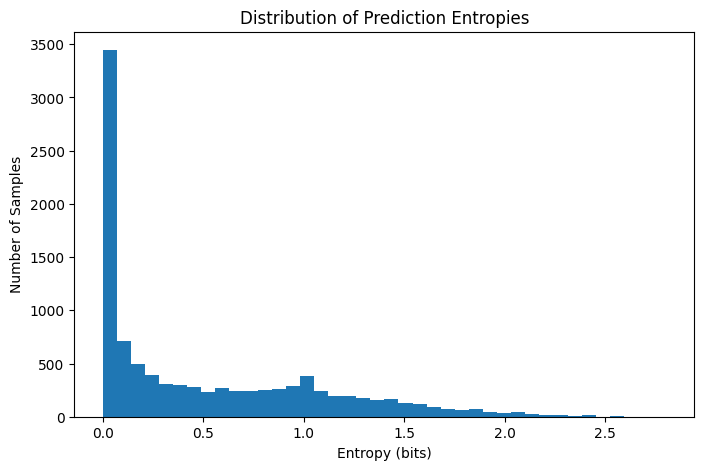

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(all_entropies, bins=40)

plt.xlabel("Entropy (bits)")
plt.ylabel("Number of Samples")
plt.title("Distribution of Prediction Entropies")

plt.show()

## Analysis: Entropy, Cross-Entropy, Confidence, and Correctness

### Key questions:
1. Are correct predictions generally more confident (lower entropy)?
2. Are wrong predictions generally more uncertain (higher entropy)?
3. Do any high-confidence (low entropy) predictions turn out to be wrong?
4. What kinds of images cause high uncertainty?

### Interpreting entropy values (10 classes):
- Entropy near 0     → extremely confident (nearly all probability on one class)
- Entropy near 2.303 → maximum uncertainty (uniform distribution across all 10 classes)
- Entropy ~0.3–0.8   → moderately confident

In [ ]:
#  Separate correct and incorrect predictions
correct_entropies   = all_entropies[all_correct]
incorrect_entropies = all_entropies[~all_correct]
correct_ce          = all_cross_entrs[all_correct]
incorrect_ce        = all_cross_entrs[~all_correct]

print("=" * 55)
print(f"{'Metric':<35} {'Correct':>8} {'Wrong':>8}")
print("=" * 55)
print(f"{'Count':<35} {all_correct.sum():>8} {(~all_correct).sum():>8}")
print(f"{'Entropy — mean':<35} {correct_entropies.mean():>8.4f} {incorrect_entropies.mean():>8.4f}")
print(f"{'Entropy — median':<35} {np.median(correct_entropies):>8.4f} {np.median(incorrect_entropies):>8.4f}")
print(f"{'Entropy — std':<35} {correct_entropies.std():>8.4f} {incorrect_entropies.std():>8.4f}")
print(f"{'Cross-entropy — mean':<35} {correct_ce.mean():>8.4f} {incorrect_ce.mean():>8.4f}")
print(f"{'Cross-entropy — median':<35} {np.median(correct_ce):>8.4f} {np.median(incorrect_ce):>8.4f}")
print("=" * 55)

#  High-confidence mistakes: the most interesting cases
# These are wrong predictions with low entropy (confident but wrong)
# Threshold: entropy below the 25th percentile of ALL entropies
low_entropy_threshold = np.percentile(all_entropies, 25)
high_conf_wrong_mask  = (~all_correct) & (all_entropies < low_entropy_threshold)

print(f"\nLow-entropy threshold (25th percentile): {low_entropy_threshold:.4f}")
print(f"\nHigh-confidence mistakes: {high_conf_wrong_mask.sum()} samples")
print(f"As % of all mistakes    : {100 * high_conf_wrong_mask.sum() / (~all_correct).sum():.1f}%")

#Some example: what did the model think vs what was true?
hcw_indices = np.where(high_conf_wrong_mask)[0][:10]
print("\nSample high-confidence mistakes:")
print(f"  {'Idx':>5}  {'True Class':<15} {'Pred Class':<15} {'Entropy':>8} {'Max Prob':>9}")
print("  " + "-" * 55)
for idx in hcw_indices:
    true_name = CLASS_NAMES[all_true_labels[idx]]
    pred_name = CLASS_NAMES[all_pred_labels[idx]]
    max_prob  = all_probs[idx].max()
    print(f"  {idx:>5}  {true_name:<15} {pred_name:<15} {all_entropies[idx]:>8.4f} {max_prob:>9.4f}")

# High-entropy correct: uncertain but right
high_entropy_threshold = np.percentile(all_entropies, 75)
uncertain_correct_mask = all_correct & (all_entropies > high_entropy_threshold)
print(f"\nHigh-entropy correct predictions: {uncertain_correct_mask.sum()} samples")
print(f"(Model was uncertain but guessed correctly)")

#Some example: what did the model think vs what was true?
hcw_indices = np.where(uncertain_correct_mask)[0][:10]
print("\nSample low-confidence correct answers:")
print(f"  {'Idx':>5}  {'True Class':<15} {'Pred Class':<15} {'Entropy':>8} {'Max Prob':>9}")
print("  " + "-" * 55)
for idx in hcw_indices:
    true_name = CLASS_NAMES[all_true_labels[idx]]
    pred_name = CLASS_NAMES[all_pred_labels[idx]]
    max_prob  = all_probs[idx].max()
    print(f"  {idx:>5}  {true_name:<15} {pred_name:<15} {all_entropies[idx]:>8.4f} {max_prob:>9.4f}")

Metric                               Correct    Wrong
Count                                   8236     1764
Entropy — mean                        0.3807   1.1297
Entropy — median                      0.1426   1.1001
Entropy — std                         0.4774   0.5331
Cross-entropy — mean                  0.1674   3.3956
Cross-entropy — median                0.0264   2.6199

Low-entropy threshold (25th percentile): 0.0228

High-confidence mistakes: 13 samples
As % of all mistakes    : 0.7%

Sample high-confidence mistakes:
    Idx  True Class      Pred Class       Entropy  Max Prob
  -------------------------------------------------------
    239  Coat            Pullover          0.0187    0.9985
   1300  Bag             Sandal            0.0138    0.9989
   2022  Sneaker         Ankle boot        0.0141    0.9987
   3067  Bag             Sneaker           0.0155    0.9987
   3531  T-shirt/top     Dress             0.0053    0.9996
   4132  Ankle boot      Sandal            0.0214   

In [ ]:
#  Per-class entropy analysis
# Some classes are inherently harder → higher average entropy on those classes
print(f"{'Class':<15} {'Accuracy':>9} {'Avg Entropy':>12} {'Avg CE Loss':>12}")
print("-" * 50)

for class_idx in range(NUM_CLASSES):
    class_mask  = all_true_labels == class_idx
    class_acc   = all_correct[class_mask].mean() * 100
    class_h     = all_entropies[class_mask].mean()
    class_ce    = all_cross_entrs[class_mask].mean()
    print(f"{CLASS_NAMES[class_idx]:<15} {class_acc:>8.1f}% {class_h:>12.4f} {class_ce:>12.4f}")

Class            Accuracy  Avg Entropy  Avg CE Loss
--------------------------------------------------
T-shirt/top         77.0%       0.7453       0.9774
Trouser             96.4%       0.0864       0.1935
Pullover            79.0%       0.7344       0.8129
Dress               78.9%       0.6545       0.9302
Coat                70.7%       0.8528       1.1025
Sandal              97.2%       0.1275       0.0969
Shirt               55.0%       0.9722       1.9075
Sneaker             84.8%       0.4297       0.6065
Bag                 93.1%       0.2709       0.3971
Ankle boot          91.5%       0.2546       0.3444


#More Box-plot Visualizations

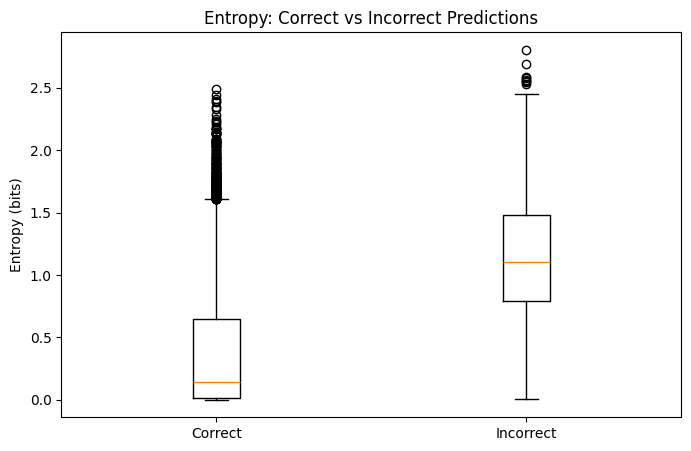

In [ ]:
plt.figure(figsize=(8,5))

plt.boxplot(
    [correct_entropies, incorrect_entropies],
    tick_labels=["Correct", "Incorrect"]
)

plt.ylabel("Entropy (bits)")
plt.title("Entropy: Correct vs Incorrect Predictions")

plt.show()

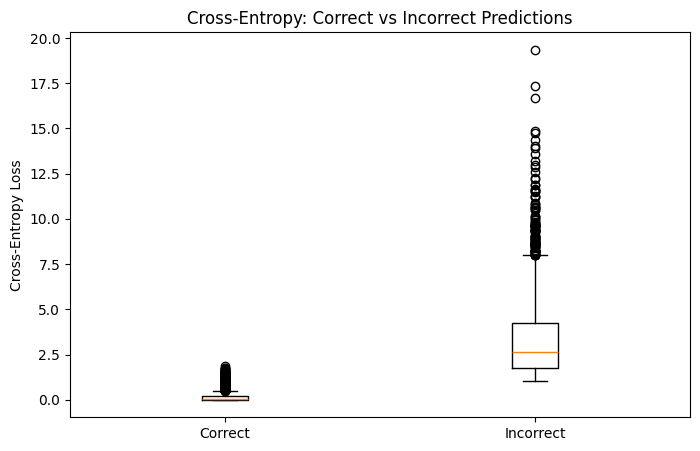

In [ ]:
plt.figure(figsize=(8,5))

plt.boxplot(
    [correct_ce, incorrect_ce],
    tick_labels=["Correct", "Incorrect"]
)

plt.ylabel("Cross-Entropy Loss")
plt.title("Cross-Entropy: Correct vs Incorrect Predictions")

plt.show()